In [80]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import yfinance as yf
import scipy.stats as stats

In [81]:
df = pd.read_excel("../financial_data/vinfast_stock_data.xlsx")

In [82]:
df

,Date,Open,High,Low,CloseClosing price adjusted for splits.,Adj CloseAdjusted closing price adjusted for splits and dividend and/or capital gain distributions.,Volume
0,2026-04-28 00:00:00,4.16,4.195,4.000,4.060,4.060,834600
1,2026-04-27 00:00:00,4.23,4.340,4.157,4.210,4.210,650700
2,2026-04-24 00:00:00,4.41,4.450,4.335,4.360,4.360,457200
3,2026-04-23 00:00:00,4.57,4.605,4.140,4.410,4.410,1333100
4,2026-04-22 00:00:00,4.88,5.120,4.580,4.690,4.690,1409000
...,...,...,...,...,...,...,...
1160,13 Sept 2021,9.71,9.710,9.710,9.710,9.710,400
1161,10 Sept 2021,9.69,9.690,9.680,9.680,9.680,700
1162,9 Sept 2021,9.61,9.691,9.610,9.682,9.682,400
1163,8 Sept 2021,9.71,9.710,9.710,9.710,9.710,3700


In [83]:
df.columns = ['date', 'open', 'high', 'low', 'close', 'adjusted_close', 'volume']

df['date'] = pd.to_datetime(df['date'], format='mixed')

In [84]:
df

,date,open,high,low,close,adjusted_close,volume
0,2026-04-28,4.16,4.195,4.000,4.060,4.060,834600
1,2026-04-27,4.23,4.340,4.157,4.210,4.210,650700
2,2026-04-24,4.41,4.450,4.335,4.360,4.360,457200
3,2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
4,2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
...,...,...,...,...,...,...,...
1160,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
1161,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
1162,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
1163,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700


In [85]:
df.isna().sum()

date              0
open              0
high              0
low               0
close             0
adjusted_close    0
volume            0
dtype: int64

In [86]:
df.duplicated().sum()

0

In [87]:
df['date'] = pd.to_datetime(df['date'], format="mixed")


In [88]:
df = df.sort_values(['date'],ascending=True) 
df


,date,open,high,low,close,adjusted_close,volume
1164,2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
1163,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
1162,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
1161,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
1160,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...,...
4,2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
3,2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
2,2026-04-24,4.41,4.450,4.335,4.360,4.360,457200
1,2026-04-27,4.23,4.340,4.157,4.210,4.210,650700


In [89]:
df.corr(numeric_only=True)

,open,high,low,close,adjusted_close
open,1.000000,0.977757,0.981945,0.966715,0.966715
high,0.977757,1.000000,0.964280,0.985586,0.985586
low,0.981945,0.964280,1.000000,0.982141,0.982141
close,0.966715,0.985586,0.982141,1.000000,1.000000
adjusted_close,0.966715,0.985586,0.982141,1.000000,1.000000


In [90]:
plt.style.use("bmh")

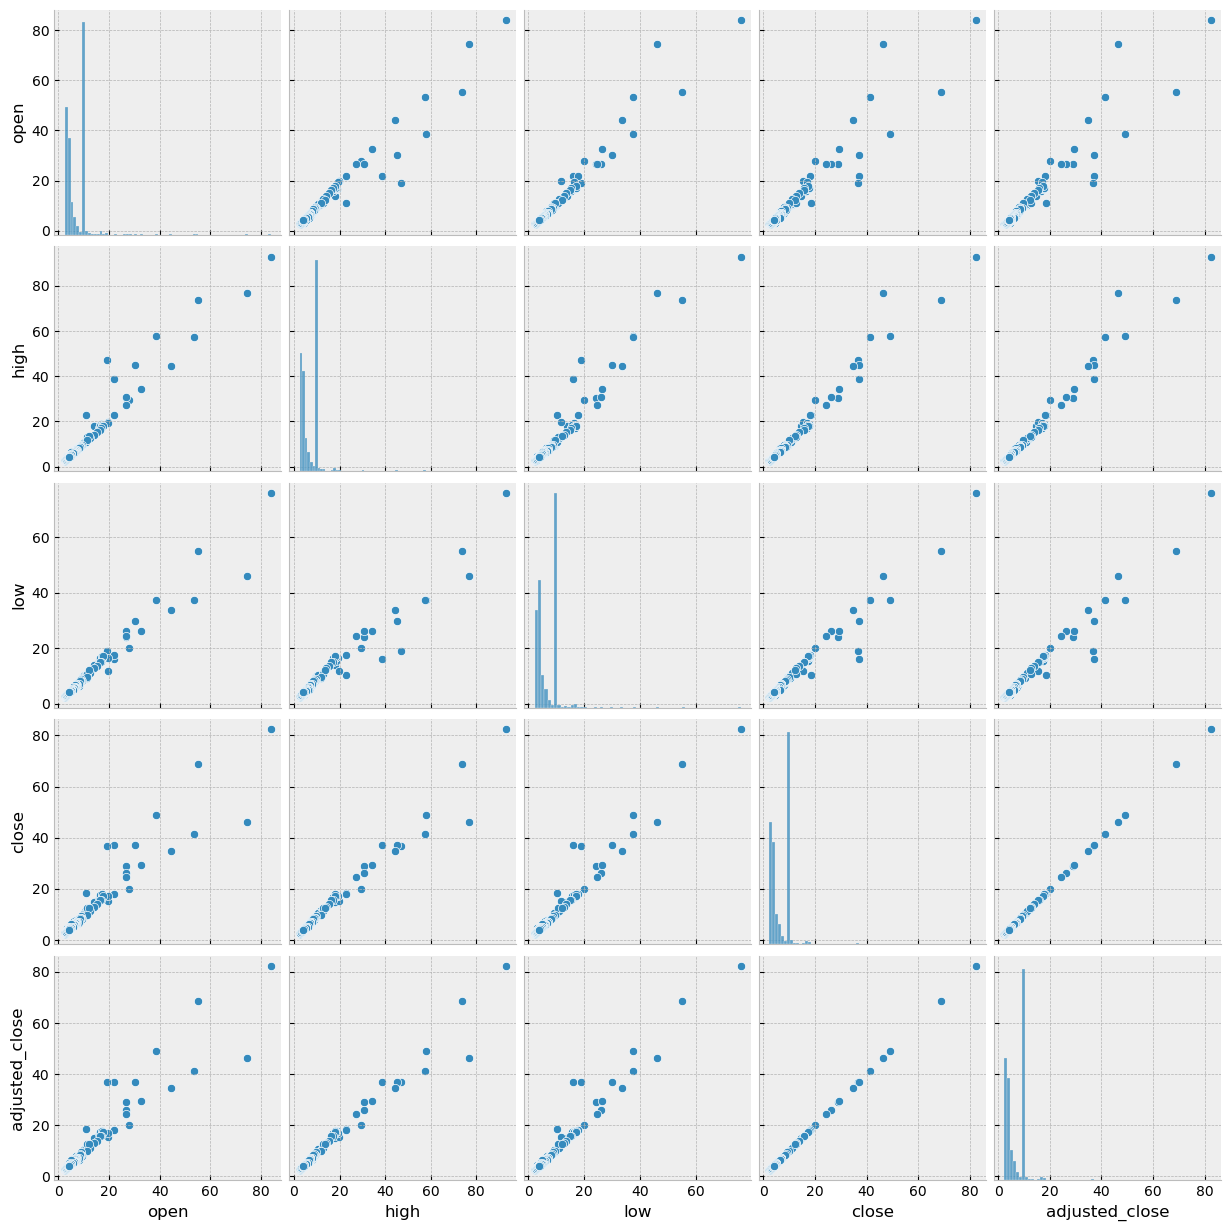

In [91]:
sns.pairplot(df)

In [92]:
df.index = df.date 
df.drop(['date'],axis=1,inplace=True) 


In [93]:
df

,open,high,low,close,adjusted_close,volume
date,,,,,,
2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2021-09-09,9.61,9.691,9.610,9.682,9.682,400
2021-09-10,9.69,9.690,9.680,9.680,9.680,700
2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...
2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
2026-04-24,4.41,4.450,4.335,4.360,4.360,457200


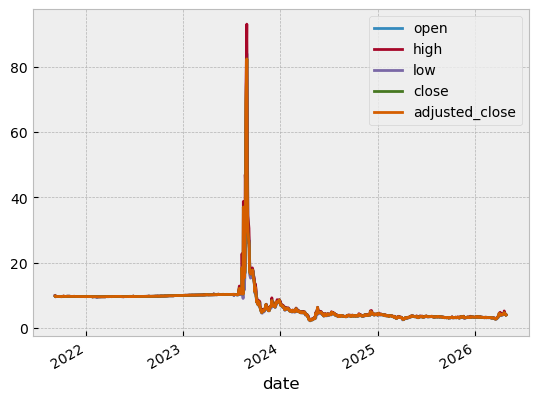

In [94]:
plt.Figure(figsize=(10,10))
df.plot(kind='line')

plt.show()

In [96]:
df.head()

,open,high,low,close,adjusted_close,volume
date,,,,,,
2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2021-09-09,9.61,9.691,9.610,9.682,9.682,400
2021-09-10,9.69,9.690,9.680,9.680,9.680,700
2021-09-13,9.71,9.710,9.710,9.710,9.710,400


In [95]:
df.drop(['date'],axis=1,inplace=True)
df.head()

KeyError: "['date'] not found in axis"

In [97]:
df.reset_index(inplace=True)

In [98]:
df

,date,open,high,low,close,adjusted_close,volume
0,2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
1,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
3,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
4,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...,...
1160,2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
1161,2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
1162,2026-04-24,4.41,4.450,4.335,4.360,4.360,457200
1163,2026-04-27,4.23,4.340,4.157,4.210,4.210,650700


In [99]:
df = df.sort_values(['date'],ascending=True)

df = df[df.date > '2024-01-01']

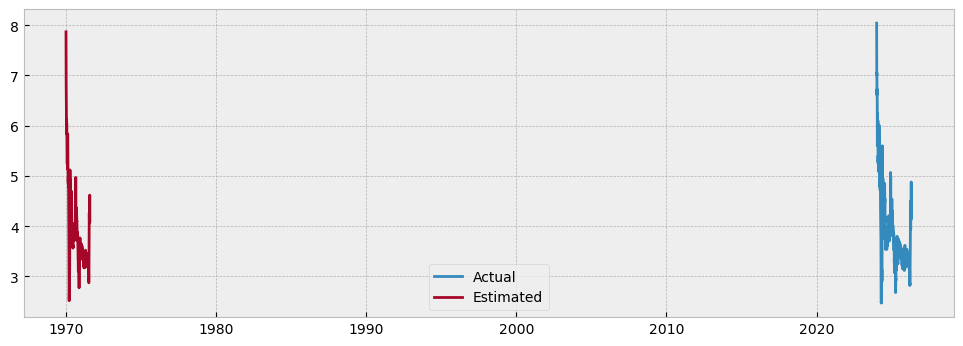

In [103]:
from statsmodels.tsa.seasonal import STL
open_price = pd.DataFrame(df[['open', 'date']])


stl = STL(open_price['open'], period=3) 
result = stl.fit()
seasonal, trend, resid = result.seasonal, result.trend, result.resid 


estimated = trend + seasonal 
plt.figure(figsize=(12,4)) 
plt.plot(open_price.date, open_price.open) 
plt.plot(estimated) 
plt.legend(['Actual', 'Estimated'])
plt.show()

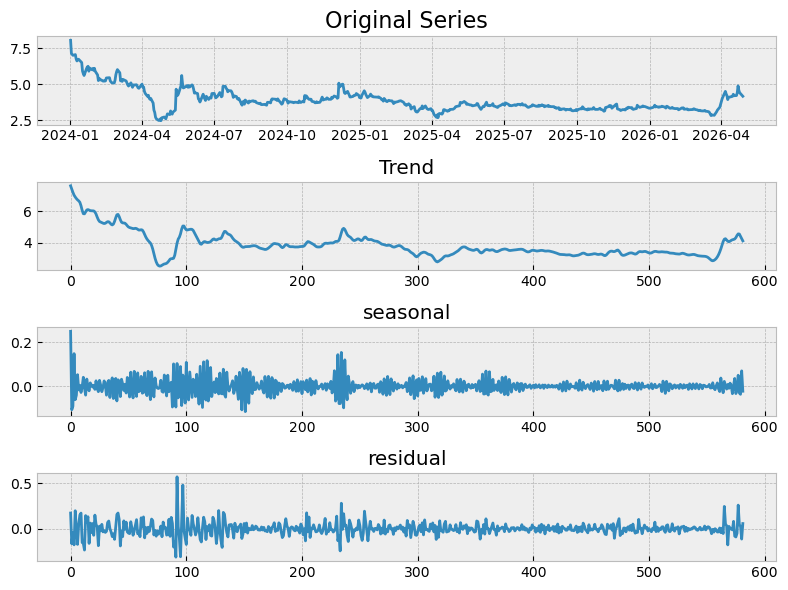

In [104]:
seasonal, trend, resid = result.seasonal, result.trend, result.resid 

plt.figure(figsize=(8,6)) 
plt.subplot(4,1,1) 
plt.plot(df.date, df['open']) 
plt.title("Original Series", fontsize=16) 

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend") 

plt.subplot(4,1,3) 
plt.plot(seasonal) 
plt.title("seasonal") 

plt.subplot(4,1,4) 
plt.plot(resid) 
plt.title("residual")
plt.tight_layout()

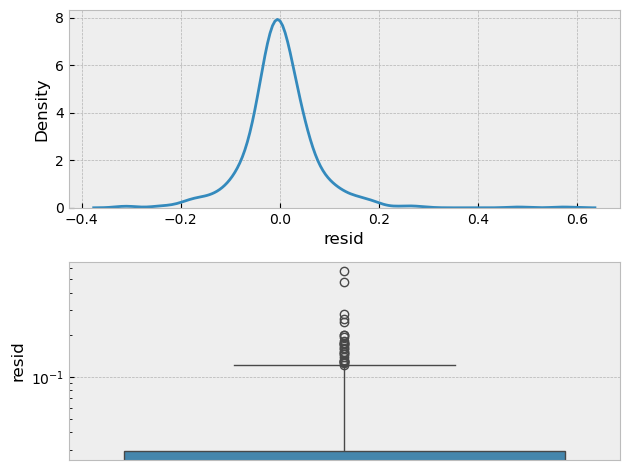

Shapiro -> ShapiroResult(statistic=0.8899385112825087, pvalue=5.828630661555075e-20)


In [105]:
fig, axes=plt.subplots(2) 

sns.kdeplot(resid, ax=axes[0])
sns.boxplot(resid, ax=axes[1])
axes[1].set_yscale("log") 
plt.tight_layout()
plt.show()

import scipy.stats as stats 


print (f"Shapiro -> {stats.shapiro(resid)}")

In [106]:
df

,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200
1,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600
2,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600
3,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900
4,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900
...,...,...,...,...,...,...,...
577,2026-04-22,4.880,5.120,4.580,4.69,4.69,1409000
578,2026-04-23,4.570,4.605,4.140,4.41,4.41,1333100
579,2026-04-24,4.410,4.450,4.335,4.36,4.36,457200
580,2026-04-27,4.230,4.340,4.157,4.21,4.21,650700


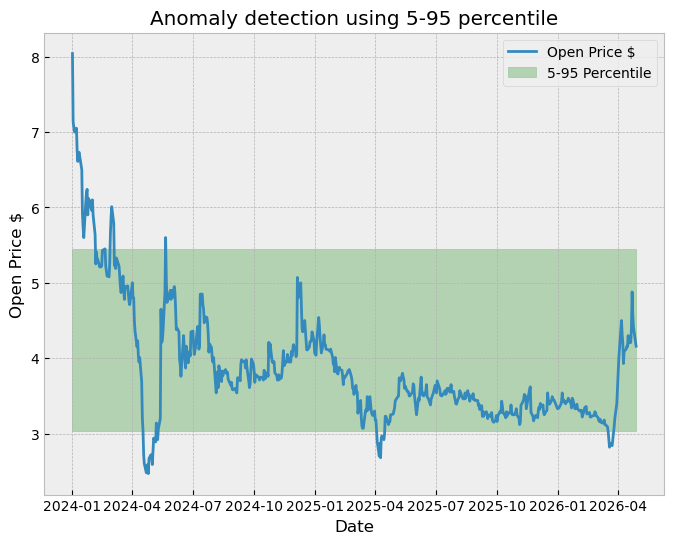

In [107]:
plt.figure(figsize=(8,6))
plt.plot(df.date, df.open) 

# plotting the median lines 

upper = np.percentile(df.open, 95) 
lower = np.percentile(df.open, 5) 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=0.25) 
plt.title("Anomaly detection using 5-95 percentile") 
plt.ylabel("Open Price $") 
plt.xlabel("Date")

plt.legend(['Open Price $', '5-95 Percentile'])
plt.show()

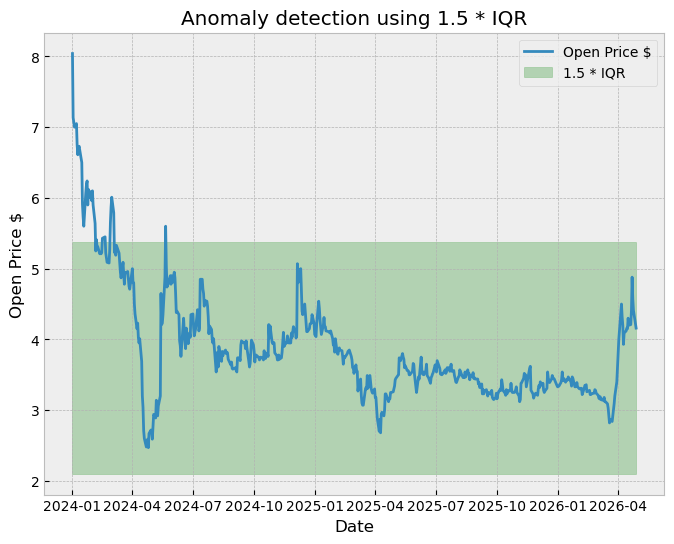

In [108]:
# using IQR

iqr = stats.iqr(df['open']) 




plt.figure(figsize=(8,6))
plt.plot(df.date, df.open) 

# plotting the median lines 

upper = (1.5 * iqr) + np.percentile(df.open, 75)
lower = np.percentile(df.open, 25) - (1.5 * iqr)

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=0.25) 
plt.title("Anomaly detection using 1.5 * IQR") 
plt.ylabel("Open Price $") 
plt.xlabel("Date")

plt.legend(['Open Price $', '1.5 * IQR'])
plt.show()

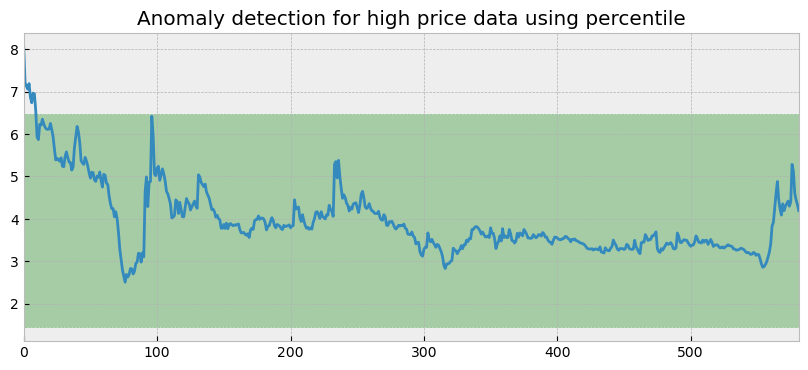

In [109]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['high'].mean() 
open_dev = df['high'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data using percentile")
plt.show()

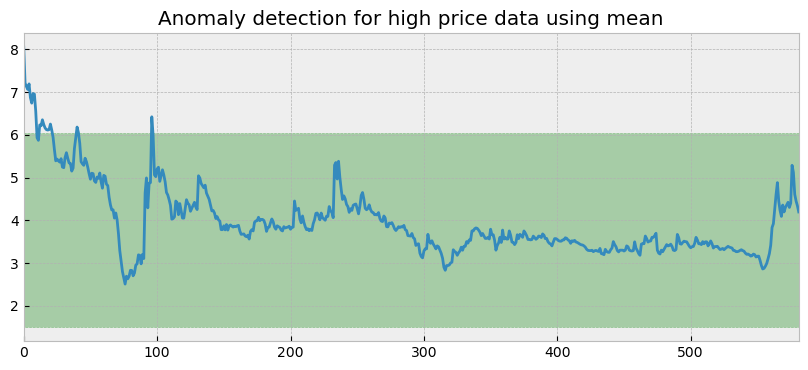

In [110]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['low'].mean() 
open_dev = df['low'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data using mean")
plt.show()

In [111]:

df.volume = pd.to_numeric(df.volume)

In [112]:
df.iloc[5]

date              2024-01-09 00:00:00
open                             6.75
high                             6.87
low                              6.41
close                            6.65
adjusted_close                   6.65
volume                        3327700
Name: 5, dtype: object

In [113]:
df.reset_index(inplace=True)

In [114]:
df.head()

,index,date,open,high,low,close,adjusted_close,volume
0,0,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
1,1,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
2,2,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
3,3,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
4,4,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


In [254]:

print ("Creating day, month, year...")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date'],ascending=True)

df['day'] = df['date'].dt.day 
df['month'] = df['date'].dt.month 
df['year'] = df['date'].dt.year

df = df.sort_values(['date'],ascending=True) 
print ("Splitting into X_train, X_test, Y_train, Y_test...")
X = df[['high','low', 'adjusted_close', 'volume', 'day', 'month', 'year']]
train_size=round(df.shape[0]*0.8)
test_size=round(df.shape[0]*0.2)
# replacing the anomalies
X_train = X.head(train_size)
 
X_test = X.tail(test_size)




def impute_median(column): 
    print (f"Computing for column: {column}")
    median = X_train[column].median() 
    print (f"median: {median}")
    std = X_train[column].std() 
    print (f"std: {std}")
    mean = X_train[column].mean() 
    print (f"mean: {mean}")
    # calculating the upper limit

    iqr = stats.iqr(df[column])


    upper = (1.5 * iqr) + np.percentile(X_train[column], 75)
    lower=np.percentile(X_train[column], 25) - (1.5 * iqr)
    print (f"upper: {upper}")
    print (f"lower: {lower}")
    # checking if the value is above or below 
    print ("Imputing...")

    values = [median if value > upper or value < lower else value for value in X_train[column]]
    print ("Done") 
    print ("----------------------")
    return values, median, upper, lower

print ("Imputing...")

# imputing mean for df['open']
iqr = stats.iqr(df['open']) 
upper = (1.5 * iqr) + np.percentile(df['open'], 75)
lower=np.percentile(df['open'], 25) - (1.5 * iqr)
median = df['open'].median()
df['open_imputed'] = [median if value > upper or value < lower else value for value in df['open']]




for column in X_train: 
    # this will impute X_train and X_test simultaneously
    print (f"column: {column}")

    X_train[f"{column}_imputed"], median, upper, lower = impute_median(column)

    
    X_test[f"{column}_imputed"] = [median if value > upper or value < lower else value for value in X_test[column]]

    print ("Done...")
    print ("------------------")




# -------------------------- CREATING THE LAGGING
y = df.open.values.reshape(-1,1)



Y_train = y[0:train_size]
Y_test = y[train_size:df.shape[0]]

X_train = X_train.drop(['day_imputed', 'month_imputed', 'year_imputed'],axis=1)
X_test = X_test.drop(['day_imputed', 'month_imputed', 'year_imputed'],axis=1)


Creating day, month, year...
Splitting into X_train, X_test, Y_train, Y_test...
Imputing...
column: high
Computing for column: high
median: 3.83
std: 0.8777066884512452
mean: 4.066912017167382
upper: 5.6602500000000004
lower: 2.1887499999999998
Imputing...
Done
----------------------
Done...
------------------
column: low
Computing for column: low
median: 3.6875
std: 0.7992202161378477
mean: 3.8586030042918456
upper: 5.203500000000001
lower: 2.241249999999999
Imputing...
Done
----------------------
Done...
------------------
column: adjusted_close
Computing for column: adjusted_close
median: 3.75
std: 0.8330754018429259
mean: 3.959388412017167
upper: 5.42375
lower: 2.2337500000000006
Imputing...
Done
----------------------
Done...
------------------
column: volume
Computing for column: volume
median: 734450.0
std: 1371466.8761462246
mean: 1186409.2274678112
upper: 2605500.0
lower: -723550.0
Imputing...
Done
----------------------
Done...
------------------
column: day
Computing for col

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1885/1613190907.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[f"{column}_imputed"], median, upper, lower = impute_median(column)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1885/1613190907.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[f"{column}_imputed"] = [median if value > upper or value < lower else value for value in X_test[column]]
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1885/16131

In [255]:
X_train

,high,low,adjusted_close,volume,day,month,year,high_imputed,low_imputed,adjusted_close_imputed,volume_imputed
0,8.050,7.000,7.05,6666200,2,1,2024,3.830,3.6875,3.75,734450.0
1,7.210,6.835,7.08,4709600,3,1,2024,3.830,3.6875,3.75,734450.0
2,7.130,6.900,7.07,3466600,4,1,2024,3.830,3.6875,3.75,734450.0
3,7.060,6.900,7.02,1939900,5,1,2024,3.830,3.6875,3.75,1939900.0
4,7.190,6.750,6.79,3767900,8,1,2024,3.830,3.6875,3.75,734450.0
...,...,...,...,...,...,...,...,...,...,...,...
461,3.220,3.130,3.18,680700,3,11,2025,3.220,3.1300,3.18,680700.0
462,3.180,3.100,3.14,641400,4,11,2025,3.180,3.1000,3.14,641400.0
463,3.440,3.140,3.40,1620000,5,11,2025,3.440,3.1400,3.40,1620000.0
464,3.455,3.295,3.40,549600,6,11,2025,3.455,3.2950,3.40,549600.0


In [256]:
print (np.shape(Y_train)) 
print (np.shape(Y_test))

(466, 1)
(116, 1)


In [257]:
print (np.shape(X_train)) 
print (np.shape(X_test))

(466, 11)
(116, 11)


In [258]:
X_test

,high,low,adjusted_close,volume,day,month,year,high_imputed,low_imputed,adjusted_close_imputed,volume_imputed
466,3.630,3.420,3.530,780000,10,11,2025,3.630,3.420,3.530,780000.0
467,3.570,3.460,3.485,277200,11,11,2025,3.570,3.460,3.485,277200.0
468,3.490,3.400,3.470,474600,12,11,2025,3.490,3.400,3.470,474600.0
469,3.510,3.330,3.360,338500,13,11,2025,3.510,3.330,3.360,338500.0
470,3.515,3.330,3.460,367200,14,11,2025,3.515,3.330,3.460,367200.0
...,...,...,...,...,...,...,...,...,...,...,...
577,5.120,4.580,4.690,1409000,22,4,2026,5.120,4.580,4.690,1409000.0
578,4.605,4.140,4.410,1333100,23,4,2026,4.605,4.140,4.410,1333100.0
579,4.450,4.335,4.360,457200,24,4,2026,4.450,4.335,4.360,457200.0
580,4.340,4.157,4.210,650700,27,4,2026,4.340,4.157,4.210,650700.0


In [259]:
df.shape

(582, 16)

In [260]:
lagged_volume = X_train['volume_imputed'].values
lagged_volume = np.insert(lagged_volume, 0, 0)
lagged_volume = lagged_volume[:-1]

X_train['lagged_volume'] = lagged_volume 

# lagged adjusted close



lagged_adjusted_close = X_train['adjusted_close_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_train['lagged_adjusted_close'] = lagged_adjusted_close



# lagged adjusted high
lagged_high = X_train['high_imputed'].values 
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
X_train['lagged_high'] = lagged_high 

# lagged low 
lagged_low = X_train['low_imputed'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
X_train['lagged_low'] = lagged_low 

X_train.head()
# ----------------------------

lagged_volume = X_test['volume_imputed'].values
lagged_volume = np.insert(lagged_volume, 0, 0)
lagged_volume = lagged_volume[:-1]

X_test['lagged_volume'] = lagged_volume 

# lagged adjusted close


lagged_adjusted_close = X_test['adjusted_close_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_test['lagged_adjusted_close'] = lagged_adjusted_close



# lagged adjusted high
lagged_high = X_test['high_imputed'].values 
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
X_test['lagged_high'] = lagged_high 

# lagged low 
lagged_low = X_test['low_imputed'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
X_test['lagged_low'] = lagged_low 







In [261]:
X_train.head()

,high,low,adjusted_close,volume,day,month,year,high_imputed,low_imputed,adjusted_close_imputed,volume_imputed,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
0,8.05,7.000,7.05,6666200,2,1,2024,3.83,3.6875,3.75,734450.0,0.0,0.00,0.00,0.0000
1,7.21,6.835,7.08,4709600,3,1,2024,3.83,3.6875,3.75,734450.0,734450.0,3.75,3.83,3.6875
2,7.13,6.900,7.07,3466600,4,1,2024,3.83,3.6875,3.75,734450.0,734450.0,3.75,3.83,3.6875
3,7.06,6.900,7.02,1939900,5,1,2024,3.83,3.6875,3.75,1939900.0,734450.0,3.75,3.83,3.6875
4,7.19,6.750,6.79,3767900,8,1,2024,3.83,3.6875,3.75,734450.0,1939900.0,3.75,3.83,3.6875


In [262]:
X_test

,high,low,adjusted_close,volume,day,month,year,high_imputed,low_imputed,adjusted_close_imputed,volume_imputed,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
466,3.630,3.420,3.530,780000,10,11,2025,3.630,3.420,3.530,780000.0,0.0,0.000,0.000,0.000
467,3.570,3.460,3.485,277200,11,11,2025,3.570,3.460,3.485,277200.0,780000.0,3.530,3.630,3.420
468,3.490,3.400,3.470,474600,12,11,2025,3.490,3.400,3.470,474600.0,277200.0,3.485,3.570,3.460
469,3.510,3.330,3.360,338500,13,11,2025,3.510,3.330,3.360,338500.0,474600.0,3.470,3.490,3.400
470,3.515,3.330,3.460,367200,14,11,2025,3.515,3.330,3.460,367200.0,338500.0,3.360,3.510,3.330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,5.120,4.580,4.690,1409000,22,4,2026,5.120,4.580,4.690,1409000.0,734450.0,4.760,5.285,4.375
578,4.605,4.140,4.410,1333100,23,4,2026,4.605,4.140,4.410,1333100.0,1409000.0,4.690,5.120,4.580
579,4.450,4.335,4.360,457200,24,4,2026,4.450,4.335,4.360,457200.0,1333100.0,4.410,4.605,4.140
580,4.340,4.157,4.210,650700,27,4,2026,4.340,4.157,4.210,650700.0,457200.0,4.360,4.450,4.335


In [263]:
X_train = X_train[['day', 'month', 'year', 'lagged_volume', 'lagged_adjusted_close', 'lagged_high', 'lagged_low']].iloc[1:]
X_test = X_test[['day', 'month', 'year', 'lagged_volume', 'lagged_adjusted_close', 'lagged_high', 'lagged_low']].iloc[1:]

Y_train = Y_train[1:]
Y_test = Y_test[1:]


X_train.head()

,day,month,year,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
1,3,1,2024,734450.0,3.75,3.83,3.6875
2,4,1,2024,734450.0,3.75,3.83,3.6875
3,5,1,2024,734450.0,3.75,3.83,3.6875
4,8,1,2024,1939900.0,3.75,3.83,3.6875
5,9,1,2024,734450.0,3.75,3.83,3.6875


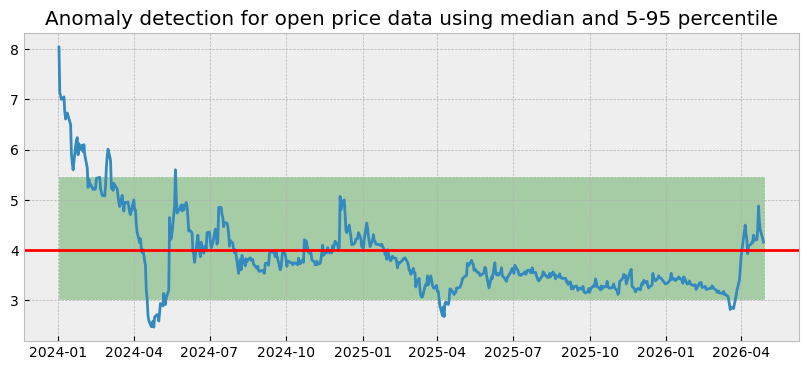

In [264]:


lower=np.percentile(df.open, 5)
upper = np.percentile(df.open, 95) 
plt.figure(figsize=(10,4)) 
plt.plot(df.date, df.open) 
plt.fill_between([min(df.date), max(df.date)], lower, upper, color='g', alpha=0.3, linestyle='--')


plt.axhline(y=4, color='r')
plt.title("Anomaly detection for open price data using median and 5-95 percentile")
plt.show()

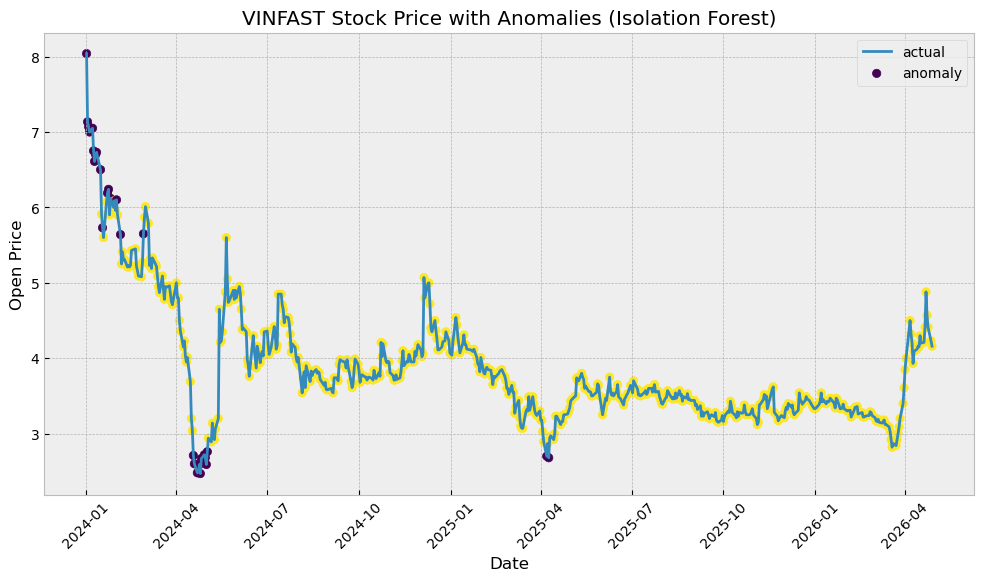

In [392]:
from sklearn.ensemble import IsolationForest

# Prepare the data for Isolation Forest
X = df['open'].values.reshape(-1, 1)

# Train the Isolation Forest model
model = IsolationForest(contamination=0.05)
model.fit(X)

# Predict the anomalies
anomalies = model.predict(X)

# Plot the anomalies
plt.figure(figsize=(12, 6))
plt.plot(df.date, df['open'])
plt.scatter(df.date, df['open'], c=anomalies, label='Anomaly')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.title('VINFAST Stock Price with Anomalies (Isolation Forest)')
plt.xticks(rotation=45)
plt.legend(['actual', 'anomaly'])
plt.grid(True)

plt.show()

In [393]:
anomalies

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  1,  1, -1, -1,  1,
       -1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

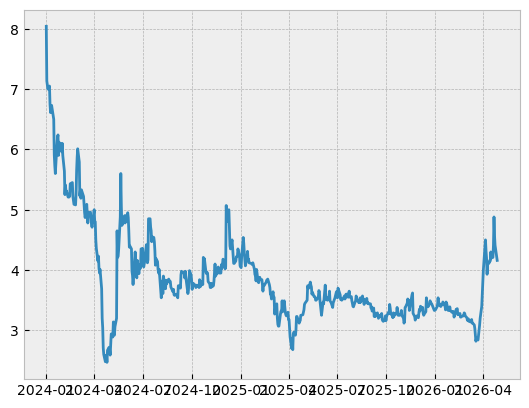

In [266]:
plt.plot(df.date, df.open)

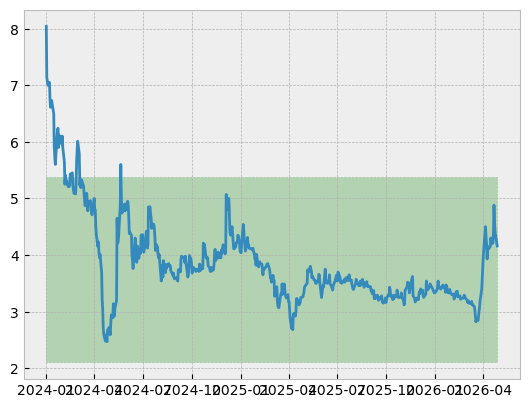

In [267]:
iqr = stats.iqr(df['open']) 

upper = (1.5*iqr) + np.percentile(df['open'], 75)
lower = np.percentile(df['open'], 25) - (1.5*iqr) 

plt.plot(df.date, df.open) 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', linestyle='--', alpha=0.25)

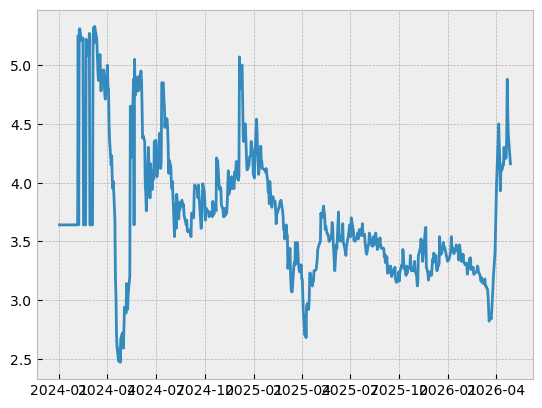

In [268]:
iqr = stats.iqr(df['open']) 

upper = (1.5*iqr) + np.percentile(df['open'], 75)
lower = np.percentile(df['open'], 25) - (1.5*iqr) 

plt.plot(df.date, df.open_imputed) 



In [269]:
df.open_imputed

0      3.64
1      3.64
2      3.64
3      3.64
4      3.64
       ... 
577    4.88
578    4.57
579    4.41
580    4.23
581    4.16
Name: open_imputed, Length: 582, dtype: float64

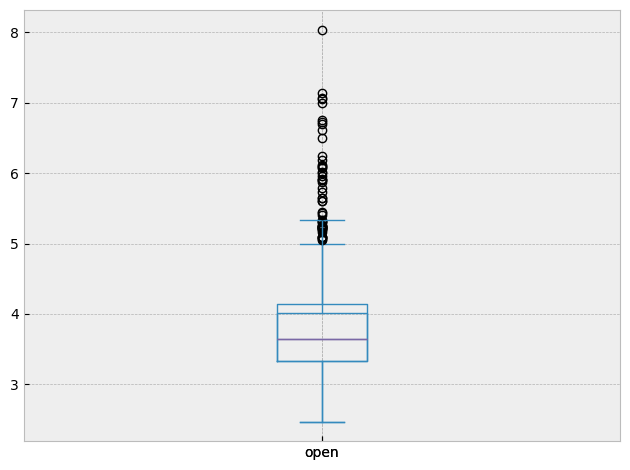

In [270]:
df['open_imputed'].plot(kind='box')
df['open'].plot(kind='box')
plt.tight_layout()

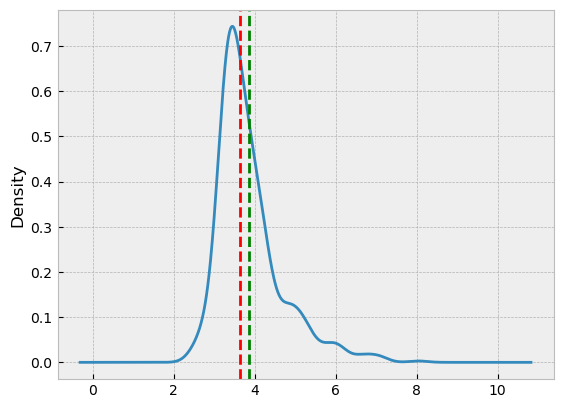

In [271]:

plt.ylabel("Open Price $")

df['open'].plot(kind='kde')
plt.axvline(x=df['open'].median(), color='r', linestyle='--')
plt.axvline(x=df['open'].mean(), color='g', linestyle='--')
plt.show()

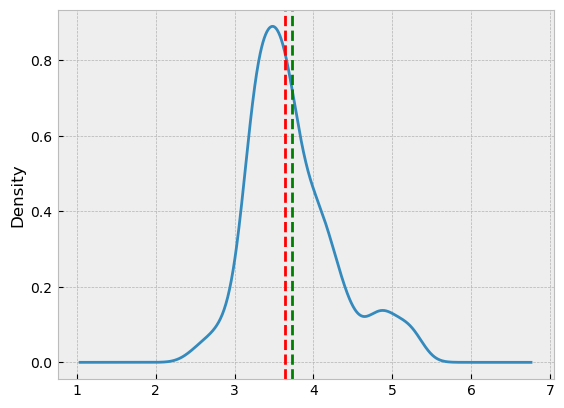

In [272]:

plt.ylabel("Open Price $ imputed")

df['open_imputed'].plot(kind='kde')
plt.axvline(x=df['open_imputed'].median(), color='r', linestyle='--')
plt.axvline(x=df['open_imputed'].mean(), color='g', linestyle='--')
plt.show()

# Building the model

In [273]:
from sklearn.model_selection import train_test_split, GridSearchCV 
from xgboost import XGBRegressor


In [274]:
print (np.shape(X_train)) 
print (np.shape(Y_train)) 
print ("---")
print (np.shape(X_test)) 
print (np.shape(Y_test))

(465, 7)
(465, 1)
---
(115, 7)
(115, 1)


In [275]:
X_train.head()

,day,month,year,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
1,3,1,2024,734450.0,3.75,3.83,3.6875
2,4,1,2024,734450.0,3.75,3.83,3.6875
3,5,1,2024,734450.0,3.75,3.83,3.6875
4,8,1,2024,1939900.0,3.75,3.83,3.6875
5,9,1,2024,734450.0,3.75,3.83,3.6875


In [276]:
"""model = XGBRegressor() 

model.fit(X_train, Y_train)"""

model = joblib.load("../models/time_series/vinfast/vinfast_open_forecaster.pkl")
pred = model.predict(X_test)

In [277]:
# metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [ ]:
print (root_mean_squared_error(y_pred=pred, y_true=Y_test))
print (mean_absolute_error(y_pred=pred, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=pred))


0.056684510429404
0.04223171132958454
0.9790685183278346


In [279]:
params = {
    'max_depth': [6, 10, 20, 30, 50, 60],
    'tree_method': ['auto', 'exact', 'hist'],
    'min_child_weight': [0,1],
    'eta': [0.01, 0.1, 0.15, 0.2, 0.3]
}


grid_search = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=params,
    verbose=3,
    return_train_score=True,
    cv=5
)
_ = grid_search.fit(X_train, Y_train) 

grid_pred = grid_search.predict(X_test)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
[CV 1/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=auto;, score=(train=0.830, test=-0.366) total time=   0.1s
[CV 2/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=auto;, score=(train=0.838, test=0.737) total time=   0.1s
[CV 3/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=auto;, score=(train=0.838, test=0.741) total time=   0.1s
[CV 4/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=auto;, score=(train=0.838, test=-0.912) total time=   0.1s
[CV 5/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=auto;, score=(train=0.839, test=-2.598) total time=   0.1s
[CV 1/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.830, test=-0.366) total time=   0.1s
[CV 2/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.838, test=0.741) total time=   0.0s
[CV 3/5] END eta=0.01, max_depth=6, min_child_wei

In [280]:
print (root_mean_squared_error(y_pred=grid_pred, y_true=Y_test))
print (mean_absolute_error(y_pred=grid_pred, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=grid_pred))

0.061990468734769065
0.04050689513165017
0.9749665323766005


In [281]:
df.tail(test_size).date

466   2025-11-10
467   2025-11-11
468   2025-11-12
469   2025-11-13
470   2025-11-14
         ...    
577   2026-04-22
578   2026-04-23
579   2026-04-24
580   2026-04-27
581   2026-04-28
Name: date, Length: 116, dtype: datetime64[ns]

In [60]:
np.shape(pred)

(232,)

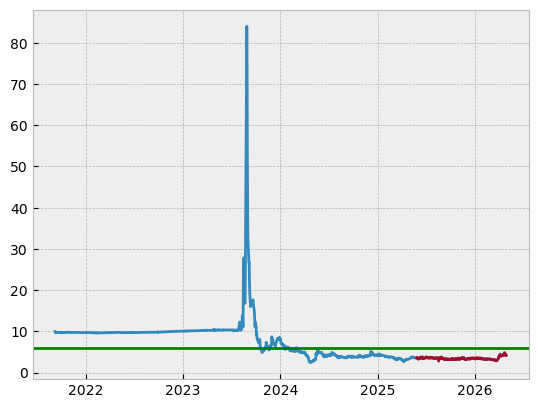

In [61]:
# plotting


plt.plot(df.date, df.open)
plt.plot(df.tail(test_size).date.iloc[1:], pred)

plt.axhline(y=df['open'].median(), color='g')

Text(0.5, 1.0, 'Zoomed in VINFAST opening prices prediction. R2 = 0.977')

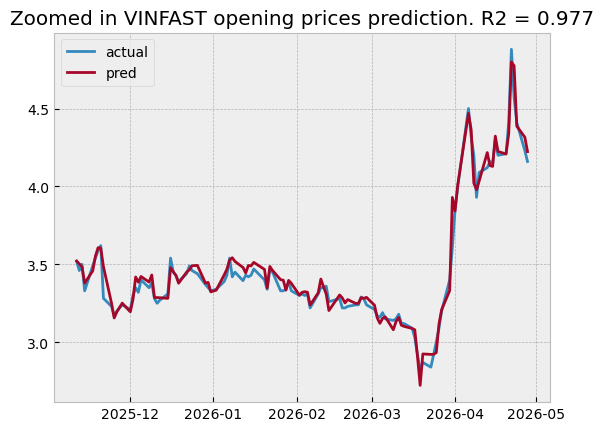

In [186]:
plt.plot(df.tail(test_size).date.iloc[1:], Y_test)
plt.plot(df.tail(test_size).date.iloc[1:], pred)

plt.legend(['actual', 'pred'])

plt.title(f"Zoomed in VINFAST opening prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")

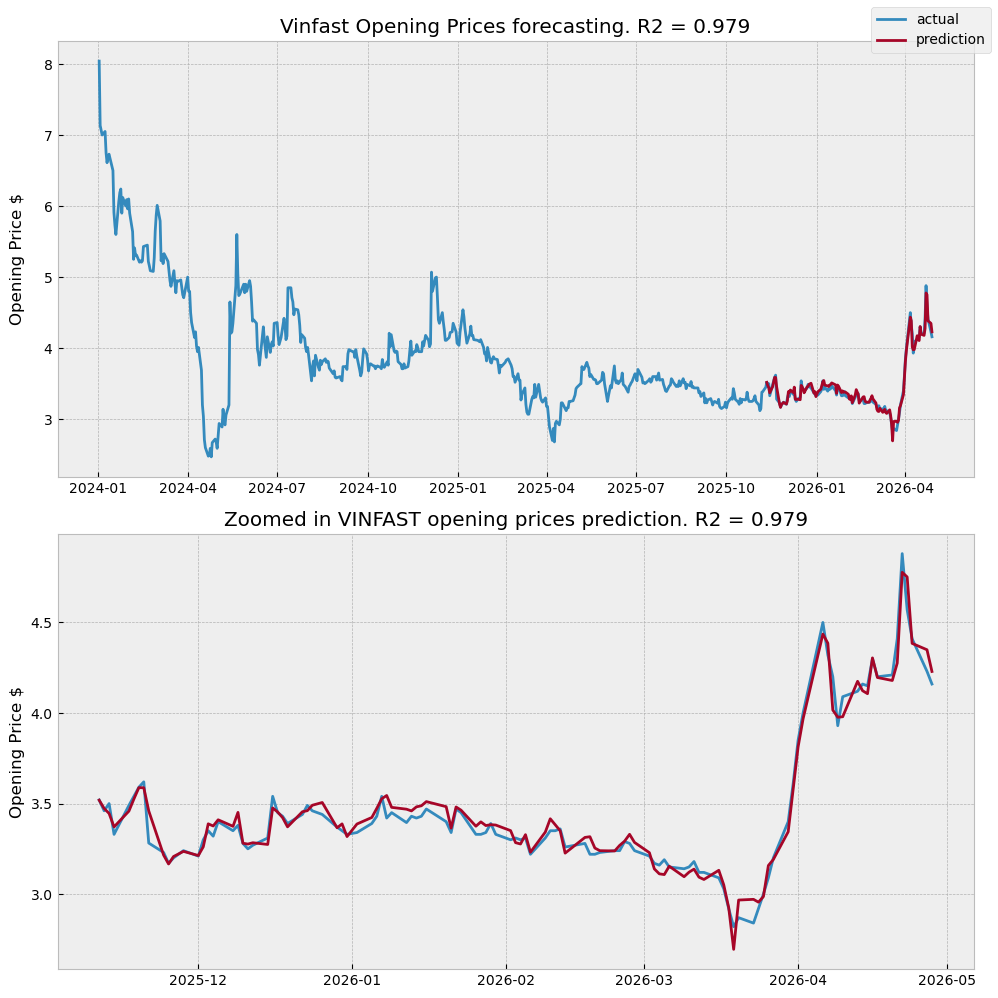

In [283]:
# plotting

fig, axes=plt.subplots(2, figsize=(10,10))




axes[0].plot(df.date, df.open)
axes[0].plot(df.tail(test_size).date.iloc[1:], pred)



axes[0].set_title(f"Vinfast Opening Prices forecasting. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")
axes[0].set_ylabel("Opening Price $")

# ---------

axes[1].plot(df.tail(test_size).date.iloc[1:], Y_test)
axes[1].plot(df.tail(test_size).date.iloc[1:], pred)



axes[1].set_title(f"Zoomed in VINFAST opening prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")
axes[1].set_ylabel("Opening Price $")
fig.legend(['actual', 'prediction'])

fig.align_ylabels()

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Y test')

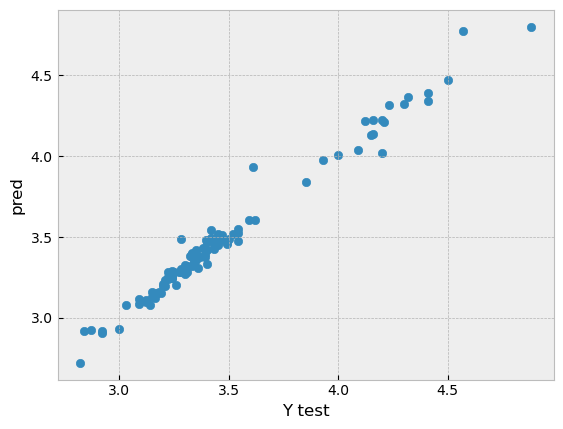

In [188]:
plt.scatter(Y_test, pred) 
plt.ylabel("pred") 
plt.xlabel("Y test")

In [65]:
X_train.shape

(931, 7)

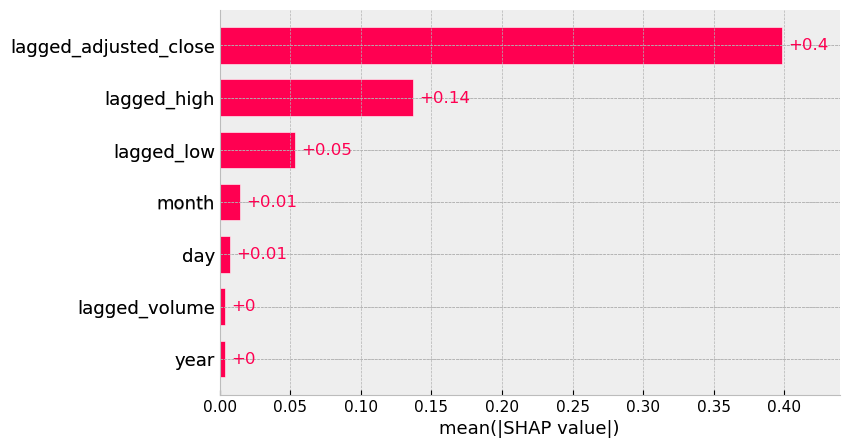

In [189]:
import shap 


explainer = shap.TreeExplainer(model) 
shap_values = explainer(X_test) 


shap.plots.bar(shap_values)

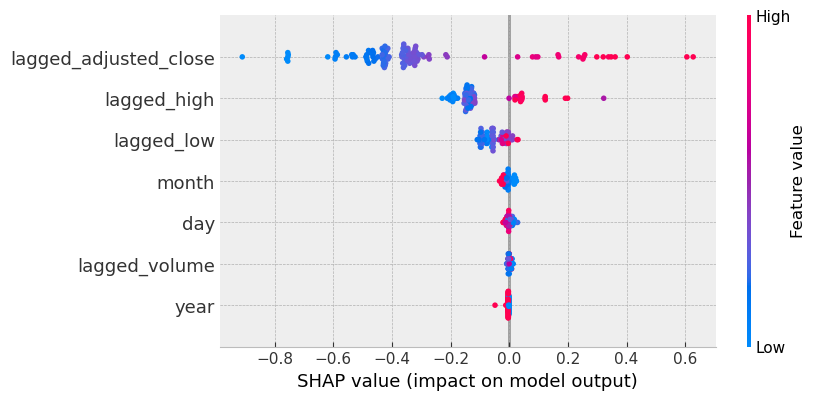

In [190]:
shap.plots.beeswarm(shap_values)

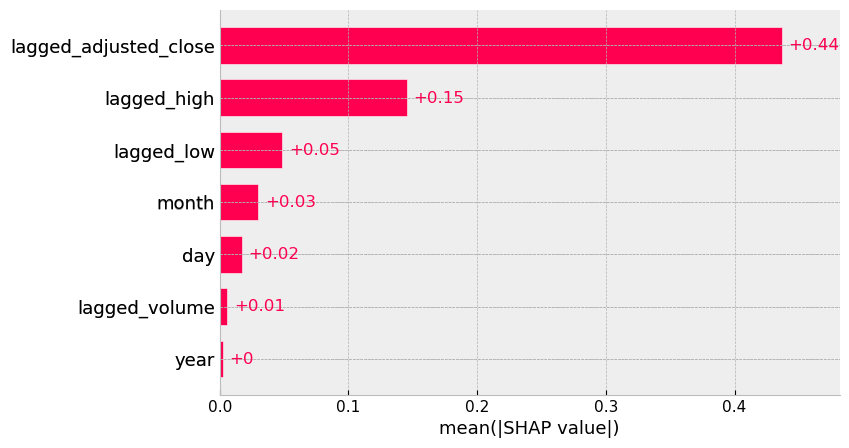

In [191]:



train_shap_values = explainer(X_train) 


shap.plots.bar(train_shap_values)

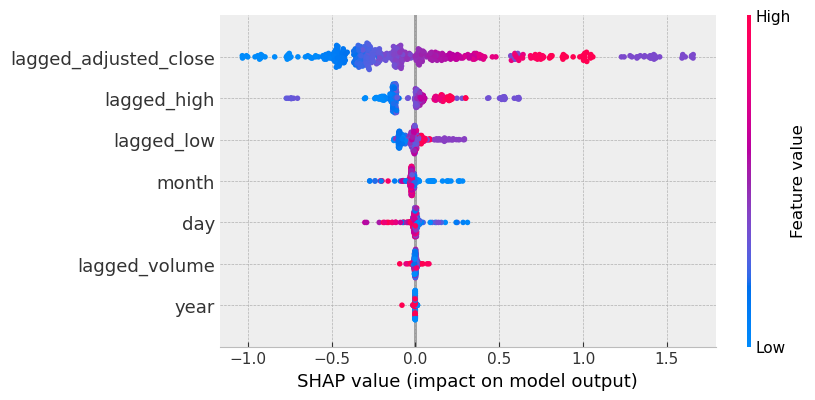

In [192]:



train_shap_values = explainer(X_train) 


shap.plots.beeswarm(train_shap_values)

In [193]:
X_test.head()

,day,month,year,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
467,11,11,2025,780000.0,3.530,3.630,3.42
468,12,11,2025,277200.0,3.485,3.570,3.46
469,13,11,2025,474600.0,3.470,3.490,3.40
470,14,11,2025,338500.0,3.360,3.510,3.33
471,17,11,2025,367200.0,3.460,3.515,3.33


In [194]:
import joblib

In [196]:
import joblib 

joblib.dump(model, "../models/time_series/vinfast_open_forecaster.pkl")

['../models/time_series/vinfast_open_forecaster.pkl']

In [239]:
import sys 
sys.path.append("../scripts/")
from clean_vinfast_stock import column_cleaner

In [288]:
print ("Predicting opening price for 1/05/2026")
model = joblib.load('../models/time_series/vinfast/vinfast_open_forecaster.pkl')
first_may = pd.DataFrame({
    'day': [1],
    'month': [5],
    'year': [2026],
    'lagged_volume': [388900],
    'lagged_adjusted_close': [4.23],
    'lagged_high': [4.26],
    'lagged_low': [4.07],
    


})

mae = 0.04223171132958454

first_may_cleaned = column_cleaner(first_may) 
first_may_cleaned = first_may_cleaned.clean_columns() 

prediction = model.predict(first_may_cleaned) 
print (f"Prediction: {prediction}")
print (f"upper bound: {prediction + mae}")
print (f"lower bound: {prediction - mae}")



Predicting opening price for 1/05/2026
Imputing 'lagged_volume'...
  Done — column 'lagged_volume' imputed.
Imputing 'lagged_adjusted_close'...
  Done — column 'lagged_adjusted_close' imputed.
Imputing 'lagged_high'...
  Done — column 'lagged_high' imputed.
Imputing 'lagged_low'...
  Done — column 'lagged_low' imputed.
   day  month  year  lagged_volume  lagged_adjusted_close  lagged_high  \
0    1      5  2026         388900                   4.23         4.26   

   lagged_low  
0        4.07  
Prediction: [4.2268715]
upper bound: [4.269103]
lower bound: [4.18464]


In [285]:
mae

0.0

# Training a "High" forecaster

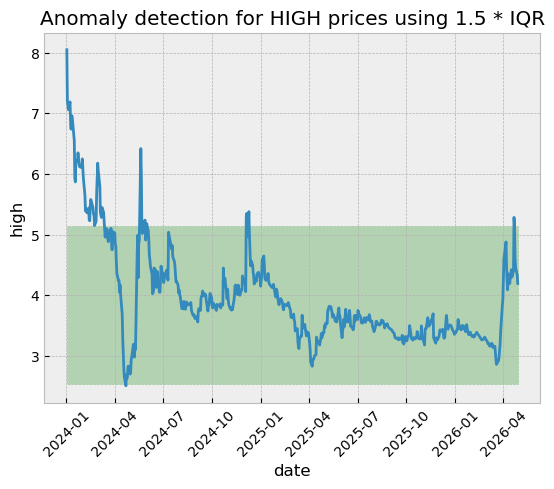

In [230]:
sns.lineplot(x=df.date, y=df.high)
plt.xticks(rotation=45)


# calculating upper and lower using iqr 
iqr = stats.iqr(df.high) 
upper = iqr + np.percentile(df.high, 75) 
lower = np.percentile(df.high, 25) - iqr 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=.25, linestyle='--')

plt.title("Anomaly detection for HIGH prices using 1.5 * IQR")


plt.show()

In [233]:
# anomaly detection using isolation forest

from sklearn.ensemble import IsolationForest

# Prepare the data
high_anomalies = df[['high']].copy()

# Fit Isolation Forest
iso_forest = IsolationForest(
    contamination='auto',  # Expected proportion of anomalies (5%)
    random_state=42,
    n_estimators=100
)

df['anomaly'] = iso_forest.fit_predict(high_anomalies)
df['anomaly_score'] = iso_forest.decision_function(high_anomalies)

# -1 = anomaly, 1 = normal
df['is_anomaly'] = df['anomaly'] == -1

# View anomalies
anomalies = df[df['is_anomaly']][['date', 'high', 'anomaly_score']]
print(f"Found {len(anomalies)} anomalies out of {len(df)} records")
print(anomalies)

Found 152 anomalies out of 582 records
          date   high  anomaly_score
0   2024-01-02  8.050      -0.288611
1   2024-01-03  7.210      -0.226131
2   2024-01-04  7.130      -0.215402
3   2024-01-05  7.060      -0.210578
4   2024-01-08  7.190      -0.223678
..         ...    ...            ...
573 2026-04-16  4.420      -0.000534
576 2026-04-21  5.285      -0.026740
577 2026-04-22  5.120      -0.019841
578 2026-04-23  4.605      -0.043257
579 2026-04-24  4.450      -0.000533

[152 rows x 3 columns]


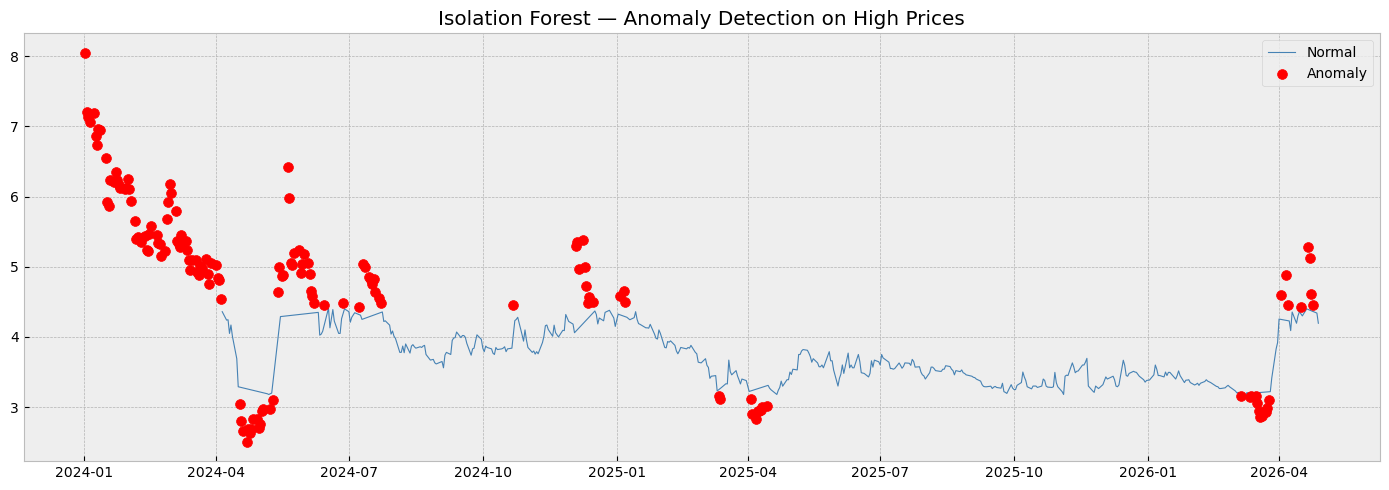

In [235]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

# Normal points
normal = df[~df['is_anomaly']]
ax.plot(normal['date'], normal['high'], color='steelblue', label='Normal', linewidth=0.8)

# Anomalies
ax.scatter(anomalies['date'], anomalies['high'],
           color='red', zorder=5, label='Anomaly', s=50)

ax.set_title('Isolation Forest — Anomaly Detection on High Prices')
ax.legend()
plt.tight_layout()
plt.show()

In [1165]:
df.head()

,date,open,high,low,close,adjusted_close,volume,day,month,year,open_imputed,high_imputed
583,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200,2,1,2024,3.64,3.74
584,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600,3,1,2024,3.64,3.74
585,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600,4,1,2024,3.64,3.74
586,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900,5,1,2024,3.64,3.74
587,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900,8,1,2024,3.64,3.74


In [331]:
# ---------- Preparing hte data to predict the high


## -------------------------------------- imputing


print ("Creating day, month, year...")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date'],ascending=True)



df = df.sort_values(['date'],ascending=True) 
print ("Splitting into X_train, X_test, Y_train, Y_test...")
X = df[['open_imputed','low', 'adjusted_close', 'volume', 'day', 'month', 'year']]
train_size=round(df.shape[0]*0.8)
test_size=round(df.shape[0]*0.2)
# replacing the anomalies
X_train = X.head(train_size)
 
X_test = X.tail(test_size)




def impute_median(column): 
    print (f"Computing for column: {column}")
    median = X_train[column].median() 
    print (f"median: {median}")
    std = X_train[column].std() 
    print (f"std: {std}")
    mean = X_train[column].mean() 
    print (f"mean: {mean}")
    # calculating the upper limit

    iqr = stats.iqr(df[column])


    upper = (1.5 * iqr) + np.percentile(X_train[column], 75)
    lower=np.percentile(X_train[column], 25) - (1.5 * iqr)
    print (f"upper: {upper}")
    print (f"lower: {lower}")
    # checking if the value is above or below 
    print ("Imputing...")

    values = [median if value > upper or value < lower else value for value in X_train[column]]
    print ("Done") 
    print ("----------------------")
    return values, median, upper, lower

print ("Imputing...")

# imputing mean for df['open']



for column in X_train: 
    # this will impute X_train and X_test simultaneously
    print (f"column: {column}")

    X_train[f"{column}_imputed"], median, upper, lower = impute_median(column)
    # saving the median values

    
    X_test[f"{column}_imputed"] = [median if value > upper or value < lower else value for value in X_test[column]]

    print ("Done...")
    print ("------------------")



# ----------- IMPUTING FOR HIGH

# imputing mean for df['open']
iqr = stats.iqr(df['high']) 
upper = (1.5 * iqr) + np.percentile(df['high'], 75)
lower=np.percentile(df['high'], 25) - (1.5 * iqr)
median = df['high'].median()
df['high_imputed'] = [median if value > upper or value < lower else value for value in df['high']]






# -------------------------- CREATING THE LAGGING
y = df.high.values.reshape(-1,1)
lagged_volume = X_train['volume_imputed'].values
lagged_volume = np.insert(lagged_volume, 0, 0)
lagged_volume = lagged_volume[:-1]

X_train['lagged_volume'] = lagged_volume 

# lagged adjusted close



lagged_adjusted_close = X_train['adjusted_close_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_train['lagged_adjusted_close'] = lagged_adjusted_close



# lagged adjusted open
lagged_open = X_train['open_imputed'].values
lagged_open = np.insert(lagged_open, 0, 0) 
lagged_open = lagged_open[:-1]
X_train['lagged_open'] = lagged_open 

# lagged low 
lagged_low = X_train['low_imputed'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
X_train['lagged_low'] = lagged_low 

X_train.head()
# ----------------------------

lagged_volume = X_test['volume_imputed'].values
lagged_volume = np.insert(lagged_volume, 0, 0)
lagged_volume = lagged_volume[:-1]

X_test['lagged_volume'] = lagged_volume 

# lagged adjusted close


lagged_adjusted_close = X_test['adjusted_close_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_test['lagged_adjusted_close'] = lagged_adjusted_close



# lagged adjusted open
lagged_open = X_test['open_imputed'].values
lagged_open = np.insert(lagged_open, 0, 0) 
lagged_open = lagged_open[:-1]
X_test['lagged_open'] = lagged_open 

# lagged low 
lagged_low = X_test['low_imputed'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
X_test['lagged_low'] = lagged_low 












Y_train = y[0:train_size]
Y_train = Y_train[1:]
Y_test = y[train_size:df.shape[0]]
Y_test = Y_test[1:]

X_train = X_train.drop(['day_imputed', 'month_imputed', 'year_imputed', 'open_imputed_imputed', 'low', 'volume', 'adjusted_close', 'open_imputed', 'low_imputed', 'volume_imputed', 'adjusted_close_imputed'],axis=1).iloc[1:]
X_test = X_test.drop(['day_imputed', 'month_imputed', 'year_imputed', 'open_imputed_imputed', 'low', 'volume', 'adjusted_close', 'open_imputed', 'low_imputed', 'volume_imputed', 'adjusted_close_imputed'],axis=1).iloc[1:]


Creating day, month, year...
Splitting into X_train, X_test, Y_train, Y_test...
Imputing...
column: open_imputed
Computing for column: open_imputed
median: 3.66
std: 0.5745859960813491
mean: 3.7936630901287547
upper: 5.0874999999999995
lower: 2.4300000000000006
Imputing...
Done
----------------------
Done...
------------------
column: low
Computing for column: low
median: 3.6875
std: 0.7992202161378477
mean: 3.8586030042918456
upper: 5.203500000000001
lower: 2.241249999999999
Imputing...
Done
----------------------
Done...
------------------
column: adjusted_close
Computing for column: adjusted_close
median: 3.75
std: 0.8330754018429259
mean: 3.959388412017167
upper: 5.42375
lower: 2.2337500000000006
Imputing...
Done
----------------------
Done...
------------------
column: volume
Computing for column: volume
median: 734450.0
std: 1371466.8761462246
mean: 1186409.2274678112
upper: 2605500.0
lower: -723550.0
Imputing...
Done
----------------------
Done...
------------------
column: day


/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1885/3927193222.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[f"{column}_imputed"], median, upper, lower = impute_median(column)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1885/3927193222.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[f"{column}_imputed"] = [median if value > upper or value < lower else value for value in X_test[column]]
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1885/39271

In [332]:
X_train.columns

Index(['day', 'month', 'year', 'lagged_volume', 'lagged_adjusted_close',
       'lagged_open', 'lagged_low'],
      dtype='object')

In [333]:
np.shape(Y_train)

(465, 1)

In [334]:
np.shape(X_train)

(465, 7)

In [335]:
np.shape(Y_test)

(115, 1)

In [336]:
np.shape(X_test)

(115, 7)

In [337]:
clf = XGBRegressor(min_child_weight=0, eta=0.3, max_depth=100) 

clf.fit(X_train, Y_train) 

high_pred = clf.predict(X_test) 

print (r2_score(y_true=Y_test, y_pred=high_pred))

print (mean_absolute_error(y_true=Y_test, y_pred=high_pred))


print (root_mean_squared_error(y_true=Y_test, y_pred=high_pred))

clf_mae = mean_absolute_error(y_true=Y_test, y_pred=high_pred)

0.7906822682891765
0.12288755373747452
0.21025625158449224


In [359]:
# attempting skopt bayes search
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer


In [380]:
param_grid = {
    'eta': Real(0.001, 0.5, prior='log-uniform'),
    'tree_method': Categorical(['auto', 'hist', 'exact', 'approx']),
    'max_depth': Integer(6, 50, prior='log-uniform'),
    'num_parallel_tree': Integer(1, 5)
    
}


grid_search = BayesSearchCV(
    estimator=XGBRegressor(n_estimators=30, min_child_weight=0),
    search_spaces=params,
    verbose=3,
    return_train_score=True,
    cv=5,
    scoring='r2',
    n_iter=100,
    n_jobs=-1
)

_ = grid_search.fit(X_train, Y_train) 

grid_pred = grid_search.predict(X_test) 

print (r2_score(y_true=Y_test, y_pred=grid_pred))

print (mean_absolute_error(y_true=Y_test, y_pred=grid_pred))


print (root_mean_squared_error(y_true=Y_test, y_pred=grid_pred))

clf_mae = mean_absolute_error(y_true=Y_test, y_pred=grid_pred)


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/skopt/space/space.py:116: UserWarning: Dimension [0, 1] was inferred to Integer(low=0, high=1, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(0, 1), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/skopt/space/space.py:116: UserWarning: Dimension [0, 1] was inferred to Integer(low=0, high=1, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(0, 1), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/skopt/space/space.py:116: UserWarning: Dimension [0, 1] was inferred to Integer(low=0, high=1, prior='uniform', transform='identity'). In u

[CV 3/5] END eta=0.01, max_depth=20, min_child_weight=0, tree_method=auto;, score=(train=0.420, test=0.170) total time=   0.0s
[CV 2/5] END eta=0.01, max_depth=20, min_child_weight=0, tree_method=auto;, score=(train=0.422, test=0.073) total time=   0.0s
[CV 5/5] END eta=0.01, max_depth=20, min_child_weight=0, tree_method=auto;, score=(train=0.417, test=-18.564) total time=   0.0s
[CV 1/5] END eta=0.01, max_depth=20, min_child_weight=0, tree_method=auto;, score=(train=0.404, test=-0.602) total time=   0.0s
[CV 4/5] END eta=0.01, max_depth=20, min_child_weight=0, tree_method=auto;, score=(train=0.417, test=-4.377) total time=   0.0s
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 4/5] END eta=0.01, max_depth=60, min_child_weight=1, tree_method=exact;, score=(train=0.417, test=-4.398) total time=   0.0s
[CV 5/5] END eta=0.01, max_depth=60, min_child_weight=1, tree_method=exact;, score=(train=0.417, test=-18.592) total time=   0.0s
[CV 3/5] END eta=0.01, max_depth=60, min_ch

/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.15, 6, 1, 'hist'] before, using random point [0.01, 10, 0, 'auto']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 2/5] END eta=0.01, max_depth=10, min_child_weight=0, tree_method=auto;, score=(train=0.422, test=0.073) total time=   0.0s
[CV 3/5] END eta=0.01, max_depth=10, min_child_weight=0, tree_method=auto;, score=(train=0.420, test=0.170) total time=   0.0s
[CV 1/5] END eta=0.01, max_depth=10, min_child_weight=0, tree_method=auto;, score=(train=0.404, test=-0.603) total time=   0.0s
[CV 4/5] END eta=0.01, max_depth=10, min_child_weight=0, tree_method=auto;, score=(train=0.417, test=-4.377) total time=   0.0s
[CV 5/5] END eta=0.01, max_depth=10, min_child_weight=0, tree_method=auto;, score=(train=0.416, test=-18.564) total time=   0.0s


...

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=hist;, score=(train=0.403, test=-0.604) total time=   0.0s
[CV 4/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=hist;, score=(train=0.415, test=-4.383) total time=   0.0s
[CV 2/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=hist;, score=(train=0.422, test=0.085) total time=   0.0s
[CV 3/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=hist;, score=(train=0.420, test=0.195) total time=   0.0s
[CV 5/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=hist;, score=(train=0.415, test=-18.564) total time=   0.0s


/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.3, 6, 0, 'auto'] before, using random point [0.3, 50, 0, 'exact']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 2/5] END eta=0.3, max_depth=50, min_child_weight=0, tree_method=exact;, score=(train=1.000, test=0.693) total time=   0.0s
[CV 1/5] END eta=0.3, max_depth=50, min_child_weight=0, tree_method=exact;, score=(train=1.000, test=-0.334) total time=   0.0s
[CV 3/5] END eta=0.3, max_depth=50, min_child_weight=0, tree_method=exact;, score=(train=1.000, test=0.094) total time=   0.0s
[CV 4/5] END eta=0.3, max_depth=50, min_child_weight=0, tree_method=exact;, score=(train=1.000, test=0.542) total time=   0.0s
[CV 5/5] END eta=0.3, max_depth=50, min_child_weight=0, tree_method=exact;, score=(train=1.000, test=-0.975) total time=   0.0s


/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.3, 6, 0, 'auto'] before, using random point [0.01, 50, 0, 'auto']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 2/5] END eta=0.01, max_depth=50, min_child_weight=0, tree_method=auto;, score=(train=0.422, test=0.073) total time=   0.0s
[CV 3/5] END eta=0.01, max_depth=50, min_child_weight=0, tree_method=auto;, score=(train=0.420, test=0.170) total time=   0.0s
[CV 1/5] END eta=0.01, max_depth=50, min_child_weight=0, tree_method=auto;, score=(train=0.404, test=-0.602) total time=   0.0s
[CV 5/5] END eta=0.01, max_depth=50, min_child_weight=0, tree_method=auto;, score=(train=0.417, test=-18.564) total time=   0.0s
[CV 4/5] END eta=0.01, max_depth=50, min_child_weight=0, tree_method=auto;, score=(train=0.417, test=-4.377) total time=   0.0s
0.8018901642934286
0.12523056317205014
0.20454973755012687


In [381]:
print (mean_absolute_error(y_true=Y_test, y_pred=grid_pred))
clf_mae=mean_absolute_error(y_true=Y_test, y_pred=grid_pred)

0.12523056317205014


In [382]:
r2_score(y_true=Y_test, y_pred=grid_pred)

0.8018901642934286

In [373]:
grid_search.best_params_

OrderedDict([('eta', 0.3),
             ('max_depth', 60),
             ('min_child_weight', 1),
             ('tree_method', 'auto')])

In [342]:
clf.get_params

<bound method XGBModel.get_params of XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eta=0.3, eval_metric=None,
             feature_types=None, feature_weights=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=100, max_leaves=None,
             min_child_weight=0, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None, ...)>

In [343]:
grid_search.best_score_

0.16123403951568735

In [344]:
clf = grid_search.best_estimator_

In [345]:
high_pred = grid_pred

In [346]:
np.array(X_train)

array([[3.0000e+00, 1.0000e+00, 2.0240e+03, ..., 3.7500e+00, 3.6400e+00,
        3.6875e+00],
       [4.0000e+00, 1.0000e+00, 2.0240e+03, ..., 3.7500e+00, 3.6400e+00,
        3.6875e+00],
       [5.0000e+00, 1.0000e+00, 2.0240e+03, ..., 3.7500e+00, 3.6400e+00,
        3.6875e+00],
       ...,
       [5.0000e+00, 1.1000e+01, 2.0250e+03, ..., 3.1400e+00, 3.1200e+00,
        3.1000e+00],
       [6.0000e+00, 1.1000e+01, 2.0250e+03, ..., 3.4000e+00, 3.1500e+00,
        3.1400e+00],
       [7.0000e+00, 1.1000e+01, 2.0250e+03, ..., 3.4000e+00, 3.3800e+00,
        3.2950e+00]])

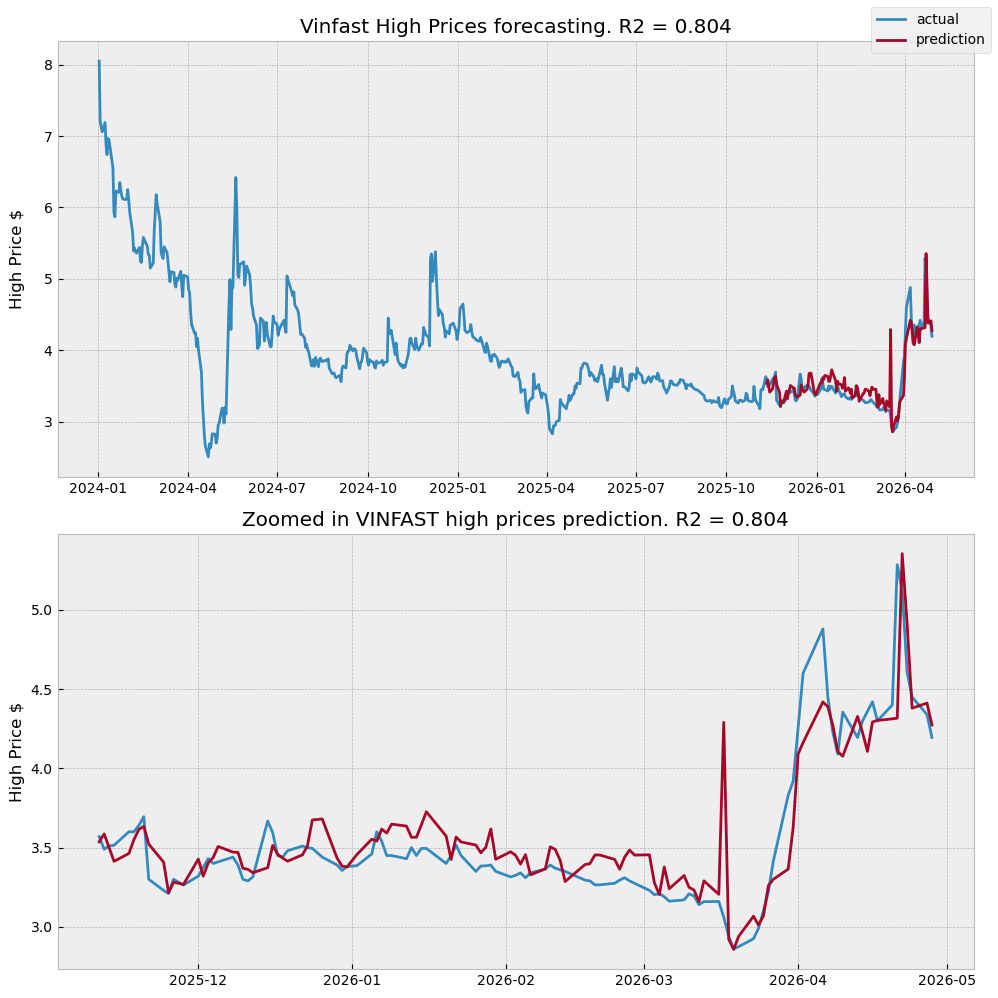

In [347]:
# plotting the lagged high 

# plotting

fig, axes=plt.subplots(2, figsize=(10,10))




axes[0].plot(df.date, df.high)
axes[0].plot(df.tail(test_size).date.iloc[1:], high_pred)



axes[0].set_title(f"Vinfast High Prices forecasting. R2 = {np.round(r2_score(y_true=Y_test, y_pred=high_pred), 3)}")
axes[0].set_ylabel("High Price $")

# ---------

axes[1].plot(df.tail(test_size).date.iloc[1:], Y_test)
axes[1].plot(df.tail(test_size).date.iloc[1:], high_pred)



axes[1].set_title(f"Zoomed in VINFAST high prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=high_pred), 3)}")
axes[1].set_ylabel("High Price $")
fig.legend(['actual', 'prediction'])

fig.align_ylabels()

plt.tight_layout()
plt.show()



Text(0, 0.5, 'high pred')

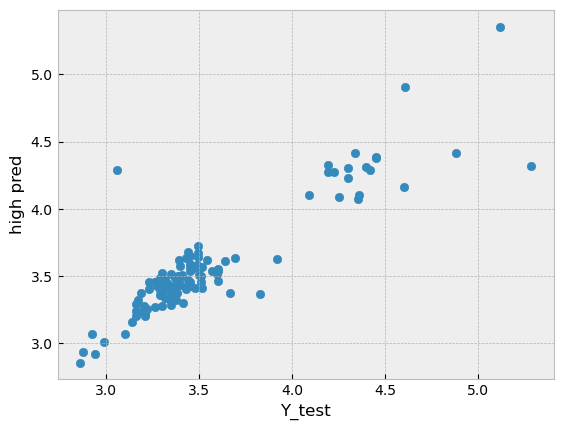

In [348]:
plt.scatter(Y_test, high_pred) 

plt.xlabel("Y_test") 
plt.ylabel("high pred")

In [349]:
X_train.columns

Index(['day', 'month', 'year', 'lagged_volume', 'lagged_adjusted_close',
       'lagged_open', 'lagged_low'],
      dtype='object')

In [350]:
X_train.columns

Index(['day', 'month', 'year', 'lagged_volume', 'lagged_adjusted_close',
       'lagged_open', 'lagged_low'],
      dtype='object')

In [351]:
# test prediction 

test_data1 = pd.DataFrame({
    'day': [30],
    'month':[4],
    'year':[2026],
    'lagged_volume': [417700],
    'lagged_adjusted_close': [4.07],
    'lagged_open': [4.1],

    'lagged_low':[4],


    



})
# cleaning 

print (test_data1)

test_data1_cleaned = column_cleaner(test_data1) 
test_data1_cleaned = test_data1_cleaned.clean_columns()



print ("Predicting the high for 30/04/2026")
test2_pred = clf.predict(test_data1_cleaned)
print (f"Prediction: {test2_pred}")
print (f"upper bound: {test2_pred + clf_mae}")
print (f"lower bound: {test2_pred - clf_mae}")


   day  month  year  lagged_volume  lagged_adjusted_close  lagged_open  \
0   30      4  2026         417700                   4.07          4.1   

   lagged_low  
0           4  
Imputing 'lagged_volume'...
  Done — column 'lagged_volume' imputed.
Imputing 'lagged_adjusted_close'...
  Done — column 'lagged_adjusted_close' imputed.
Imputing 'lagged_open'...
  Done — column 'lagged_open' imputed.
Imputing 'lagged_low'...
  Done — column 'lagged_low' imputed.
   day  month  year  lagged_volume  lagged_adjusted_close  lagged_open  \
0   30      4  2026         417700                   4.07          4.1   

   lagged_low  
0           4  
Predicting the high for 30/04/2026
Prediction: [4.1568556]
upper bound: [4.2822967]
lower bound: [4.0314145]


In [352]:
mae

0.04223171132958454

In [222]:
# test prediction 

test_data2 = pd.DataFrame({

    'open_imputed': [4.16],
    'day': [29],
    'month':[4],
    'year':[2026],
    'low_imputed':[4],
    'adjusted_close_imputed': [4.06],
    'volume_imputed': [836900]
    



})
for column in test_data2:
    print (column)
    if column != "day" and column != "month" and column != "year":
        

        median = joblib.load(f"../models/time_series/vinfast/median_lower_upper/{column}_median.pkl")
        upper  = joblib.load(f"../models/time_series/vinfast/median_lower_upper/{column}_upper.pkl")
        lower  = joblib.load(f"../models/time_series/vinfast/median_lower_upper/{column}_lower.pkl")

        test_data2[column] = [median if value > upper or value < lower else value for value in test_data1[column]]
    else:
        pass



print ("Predicting the high for 29/04/2026")
test2_pred = clf.predict(test_data2)
print (f"Prediction: {test2_pred}")
print (f"upper bound: {test2_pred + clf_mae}")
print (f"lower bound: {test2_pred - clf_mae}")


open_imputed


FileNotFoundError: [Errno 2] No such file or directory: '../models/time_series/vinfast/median_lower_upper/open_imputed_median.pkl'

In [223]:
joblib.dump(clf, '../models/time_series/vinfast/vinfast_high_forecaster.pkl')

['../models/time_series/vinfast/vinfast_high_forecaster.pkl']

In [ ]:
# predicting opening priee 

In [384]:
type(df['open'])

pandas.core.series.Series

In [390]:
type(df.index)

pandas.core.indexes.range.RangeIndex

In [391]:
type(df.date)

pandas.core.series.Series

In [389]:
type(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   index           582 non-null    int64         
 1   date            582 non-null    datetime64[ns]
 2   open            582 non-null    float64       
 3   high            582 non-null    float64       
 4   low             582 non-null    float64       
 5   close           582 non-null    float64       
 6   adjusted_close  582 non-null    float64       
 7   volume          582 non-null    int64         
 8   day             582 non-null    int32         
 9   month           582 non-null    int32         
 10  year            582 non-null    int32         
 11  open_imputed    582 non-null    float64       
 12  high_imputed    582 non-null    float64       
 13  anomaly         582 non-null    int64         
 14  anomaly_score   582 non-null    float64       
 15  is_ano

NoneType

In [387]:
for value in df.info():
    print (value)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   index           582 non-null    int64         
 1   date            582 non-null    datetime64[ns]
 2   open            582 non-null    float64       
 3   high            582 non-null    float64       
 4   low             582 non-null    float64       
 5   close           582 non-null    float64       
 6   adjusted_close  582 non-null    float64       
 7   volume          582 non-null    int64         
 8   day             582 non-null    int32         
 9   month           582 non-null    int32         
 10  year            582 non-null    int32         
 11  open_imputed    582 non-null    float64       
 12  high_imputed    582 non-null    float64       
 13  anomaly         582 non-null    int64         
 14  anomaly_score   582 non-null    float64       
 15  is_ano

TypeError: 'NoneType' object is not iterable

In [396]:
a = [("Thomas", 1, 2, 3), ("Natalie", 3, 4, 5)]
a


[('Thomas', 1, 2, 3), ('Natalie', 3, 4, 5)]

In [398]:
a[0][0]

'Thomas'

In [399]:
df

,index,date,open,high,low,close,adjusted_close,volume,day,month,year,open_imputed,high_imputed,anomaly,anomaly_score,is_anomaly
0,0,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200,2,1,2024,3.64,3.740,-1,-0.288611,True
1,1,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600,3,1,2024,3.64,3.740,-1,-0.226131,True
2,2,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600,4,1,2024,3.64,3.740,-1,-0.215402,True
3,3,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900,5,1,2024,3.64,3.740,-1,-0.210578,True
4,4,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900,8,1,2024,3.64,3.740,-1,-0.223678,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,577,2026-04-22,4.880,5.120,4.580,4.69,4.69,1409000,22,4,2026,4.88,5.120,-1,-0.019841,True
578,578,2026-04-23,4.570,4.605,4.140,4.41,4.41,1333100,23,4,2026,4.57,4.605,-1,-0.043257,True
579,579,2026-04-24,4.410,4.450,4.335,4.36,4.36,457200,24,4,2026,4.41,4.450,-1,-0.000533,True
580,580,2026-04-27,4.230,4.340,4.157,4.21,4.21,650700,27,4,2026,4.23,4.340,1,0.026622,False


In [414]:
df = df[['date', 'open', 'adjusted_close', 'close', 'high', 'low', 'day', 'month', 'year']]

In [415]:
df

,date,open,adjusted_close,close,high,low,day,month,year
0,2024-01-02,8.040,7.05,7.05,8.050,7.000,2,1,2024
1,2024-01-03,7.135,7.08,7.08,7.210,6.835,3,1,2024
2,2024-01-04,7.070,7.07,7.07,7.130,6.900,4,1,2024
3,2024-01-05,7.000,7.02,7.02,7.060,6.900,5,1,2024
4,2024-01-08,7.050,6.79,6.79,7.190,6.750,8,1,2024
...,...,...,...,...,...,...,...,...,...
577,2026-04-22,4.880,4.69,4.69,5.120,4.580,22,4,2026
578,2026-04-23,4.570,4.41,4.41,4.605,4.140,23,4,2026
579,2026-04-24,4.410,4.36,4.36,4.450,4.335,24,4,2026
580,2026-04-27,4.230,4.21,4.21,4.340,4.157,27,4,2026


In [416]:
import sys 
sys.path.append("../scripts/")
from clean_time_series import clean_iqr

In [417]:
df.columns

Index(['date', 'open', 'adjusted_close', 'close', 'high', 'low', 'day',
       'month', 'year'],
      dtype='object')

In [418]:
b = clean_iqr(df)

In [419]:
b_transformed, b_stats = b.fit_transform()

Using the 1.5 * IQR method for anomaly detection...
`date` is a datetime. Ignoring this...
Analysing column: open
Analysing column: adjusted_close
Analysing column: close
Analysing column: high
Analysing column: low
`day` is a datetime. Ignoring this...
`month` is a datetime. Ignoring this...
`year` is a datetime. Ignoring this...


/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df[f"{column}_iqr_imputed"] = [median if value > upper or value < lower else value for value in self.df[column]]
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df[f"{column}_iqr_imputed"] = [median if value > upper or value < lower else value for value in self.df[column]]
/Users

In [420]:
b_transformed

,date,open,adjusted_close,close,high,low,day,month,year,open_iqr_imputed,adjusted_close_iqr_imputed,close_iqr_imputed,high_iqr_imputed,low_iqr_imputed
0,2024-01-02,8.040,7.05,7.05,8.050,7.000,2,1,2024,3.64,3.62,3.62,3.740,3.5575
1,2024-01-03,7.135,7.08,7.08,7.210,6.835,3,1,2024,3.64,3.62,3.62,3.740,3.5575
2,2024-01-04,7.070,7.07,7.07,7.130,6.900,4,1,2024,3.64,3.62,3.62,3.740,3.5575
3,2024-01-05,7.000,7.02,7.02,7.060,6.900,5,1,2024,3.64,3.62,3.62,3.740,3.5575
4,2024-01-08,7.050,6.79,6.79,7.190,6.750,8,1,2024,3.64,3.62,3.62,3.740,3.5575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,2026-04-22,4.880,4.69,4.69,5.120,4.580,22,4,2026,4.88,4.69,4.69,5.120,4.5800
578,2026-04-23,4.570,4.41,4.41,4.605,4.140,23,4,2026,4.57,4.41,4.41,4.605,4.1400
579,2026-04-24,4.410,4.36,4.36,4.450,4.335,24,4,2026,4.41,4.36,4.36,4.450,4.3350
580,2026-04-27,4.230,4.21,4.21,4.340,4.157,27,4,2026,4.23,4.21,4.21,4.340,4.1570


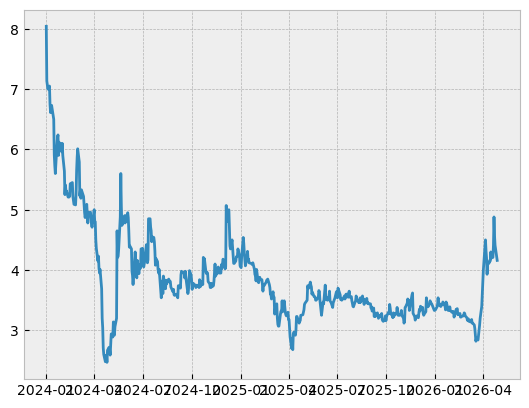

In [409]:
plt.plot(df.date, df.open)

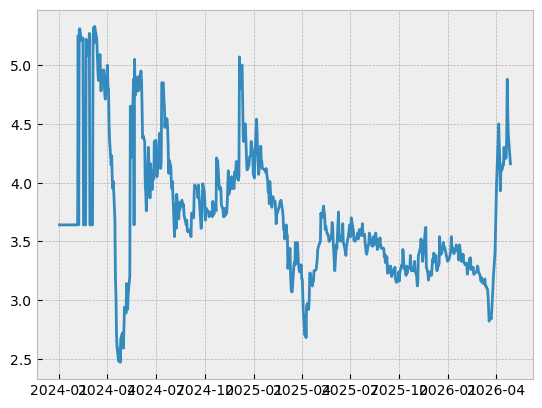

In [422]:
plt.plot(b_transformed.date, b_transformed.open_iqr_imputed)